### Opdracht 1 K-means clusering

We gaan k-means clustering implementeren zonder externe libraries

Stel er zijn volgende tuples gegeven.
(1,1), (2,1), (4,5), (5,4)

Maak er een lijst van.

In [9]:
punten = [(1, 1), (2, 1), (4, 5), (5, 4)]
print("Punten:", punten)

Punten: [(1, 1), (2, 1), (4, 5), (5, 4)]


Kies 2 punten (tuples) waar we beginnen (Hoeft niet een van die punten te zijn). Welke datastructuur ga je gebruiken?

In [10]:
# We kiezen 2 startpunten (hoeven niet in de lijst te zitten)
# Een list is handig: makkelijk aan te passen en te indexen
centroids = [(1, 1), (5, 5)]
print("Startpunten:", centroids)

Startpunten: [(1, 1), (5, 5)]


Maak een functie die de afstand bepaalt tussen 2 punten.

    def dist(a, b):
        ...
        return afstand

In [11]:
import math

def dist(a, b):
    afstand = math.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2)
    return afstand

# Even testen
print("Afstand (1,1) -> (4,5):", round(dist((1,1), (4,5)), 2))

Afstand (1,1) -> (4,5): 5.0


In de eerste stap gaan we door alle punten en voegen ze toe aan 2 clusters. Gebruik je **dist** functie en de 2 startpunten om te bepalen in welke cluster de punten terechtkomen. 

Gebruik een datastructuur naar keuze. 

Welke is handig hier? Waarom?

In [12]:
# Een dictionary is hier handig: de key is het clusternummer,
# de value is een lijst van punten. Zo kun je makkelijk
# per cluster de punten opslaan en later ophalen.

def maak_clusters(punten, centroids):
    clusters = {0: [], 1: []}

    for punt in punten:
        afstand_0 = dist(punt, centroids[0])
        afstand_1 = dist(punt, centroids[1])

        if afstand_0 <= afstand_1:
            clusters[0].append(punt)
        else:
            clusters[1].append(punt)

    return clusters

clusters = maak_clusters(punten, centroids)
print("Cluster 0:", clusters[0])
print("Cluster 1:", clusters[1])

Cluster 0: [(1, 1), (2, 1)]
Cluster 1: [(4, 5), (5, 4)]


Aan de hand van de gevonden clusters bereken nieuwe centroids

In [13]:
def bereken_centroids(clusters):
    nieuwe_centroids = []

    for key in clusters:
        punten_in_cluster = clusters[key]

        # Gemiddelde x en gemiddelde y
        gem_x = sum(p[0] for p in punten_in_cluster) / len(punten_in_cluster)
        gem_y = sum(p[1] for p in punten_in_cluster) / len(punten_in_cluster)

        nieuwe_centroids.append((gem_x, gem_y))

    return nieuwe_centroids

centroids = bereken_centroids(clusters)
print("Nieuwe centroids:", centroids)

Nieuwe centroids: [(1.5, 1.0), (4.5, 4.5)]


Herhaal de voorgaande stappen indien nodig.

In [14]:
# Herhaal tot de centroids niet meer veranderen
for stap in range(10):
    oude_centroids = centroids.copy()
    clusters = maak_clusters(punten, centroids)
    centroids = bereken_centroids(clusters)

    print(f"Stap {stap + 1}: centroids = {centroids}")

    # Stop als de centroids niet meer veranderen
    if centroids == oude_centroids:
        print(f"\nGestopt na {stap + 1} stappen, centroids veranderen niet meer.")
        break

print(f"\nEindresultaat:")
print(f"  Cluster 0: {clusters[0]}")
print(f"  Cluster 1: {clusters[1]}")

Stap 1: centroids = [(1.5, 1.0), (4.5, 4.5)]

Gestopt na 1 stappen, centroids veranderen niet meer.

Eindresultaat:
  Cluster 0: [(1, 1), (2, 1)]
  Cluster 1: [(4, 5), (5, 4)]



Probeer je code te runnen met veel meer punten. Wat kun je hier over zeggen?

In [15]:
import random

# Genereer 100 random punten
random.seed(42)
veel_punten = [(random.uniform(0, 10), random.uniform(0, 10)) for _ in range(100)]

# Start met 2 willekeurige centroids
centroids_groot = [(2, 2), (8, 8)]

for stap in range(20):
    oude = centroids_groot.copy()
    clusters_groot = maak_clusters(veel_punten, centroids_groot)
    centroids_groot = bereken_centroids(clusters_groot)

    if centroids_groot == oude:
        print(f"Gestopt na {stap + 1} stappen")
        break

print(f"Centroids: {[(round(c[0],2), round(c[1],2)) for c in centroids_groot]}")
print(f"Cluster 0: {len(clusters_groot[0])} punten")
print(f"Cluster 1: {len(clusters_groot[1])} punten")

# Met meer punten duurt het langer om te convergeren,
# maar het algoritme werkt nog steeds hetzelfde.
# Bij veel punten worden de clusters wel stabieler.

Gestopt na 7 stappen
Centroids: [(2.36, 4.25), (7.78, 5.23)]
Cluster 0: 52 punten
Cluster 1: 48 punten


### Opdracht 2: Experimenteren met PCA

In deze opdracht ga je kennismaken met Principal Component Analysis (PCA) door een bekende dataset te gebruiken: de Iris dataset. Je onderzoekt eerst hoe de data eruitziet, voert vervolgens PCA uit en bekijkt wat er verandert.

### Laad de Iris dataset
Gebruik de functie 

    load_iris()

uit scikit-learn om de dataset binnen te halen.
De Iris dataset bevat twee belangrijke onderdelen:

    .data

Dit is een matrix (2D array) met alle numerieke kenmerken van de bloemen.
Elke rij is een bloem, elke kolom is een feature (bijv. kelkblad-lengte, kelkblad-breedte, etc.).


    .target
    
Dit is een vector (1D array) met labels: welke soort Iris-bloem het is voor elke rij in .data.


Leg kort uit wat deze twee onderdelen voorstellen.

In [16]:
from sklearn.datasets import load_iris

iris = load_iris()

# .data = de numerieke kenmerken van elke bloem (150 bloemen x 4 features)
# .target = het label (soort bloem): 0, 1, of 2
print("Data shape:", iris.data.shape)
print("Target shape:", iris.target.shape)

# .data bevat per bloem 4 metingen: kelkblad lengte, kelkblad breedte,
# bloemblad lengte, bloemblad breedte.
# .target zegt welke soort het is (setosa, versicolor, virginica).

Data shape: (150, 4)
Target shape: (150,)


### Bekijk de ruwe data

Print de eerste 5 rijen van .data.
Dit geeft je een beeld van de oorspronkelijke kenmerken vóór de PCA.

In [17]:
print("Eerste 5 rijen van de data:")
for rij in iris.data[:5]:
    print(f"  {rij}")

Eerste 5 rijen van de data:
  [5.1 3.5 1.4 0.2]
  [4.9 3.  1.4 0.2]
  [4.7 3.2 1.3 0.2]
  [4.6 3.1 1.5 0.2]
  [5.  3.6 1.4 0.2]


### Pas PCA toe

- Maak een PCA-model met:

        PCA(n_components=2)


- Transformeer de dataset, zodat je nieuwe data krijgt met slechts 2 hoofcomponenten.


- Print opnieuw de eerste 5 rijen, maar nu van de getransformeerde data (dus na PCA).




In [18]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA(n_components=2)
data_pca = pca.fit_transform(iris.data)

print("Originele data shape:", iris.data.shape)
print("Na PCA shape:", data_pca.shape)
print("\nEerste 5 rijen na PCA:")
for rij in data_pca[:5]:
    print(f"  [{rij[0]:7.4f}, {rij[1]:7.4f}]")

Originele data shape: (150, 4)
Na PCA shape: (150, 2)

Eerste 5 rijen na PCA:
  [-2.6841,  0.3194]
  [-2.7141, -0.1770]
  [-2.8890, -0.1449]
  [-2.7453, -0.3183]
  [-2.7287,  0.3268]


### Visualisatie

Maak een scatterplot met de twee PCA-componenten.
Geef eventueel verschillende kleuren voor de drie Iris‑soorten.

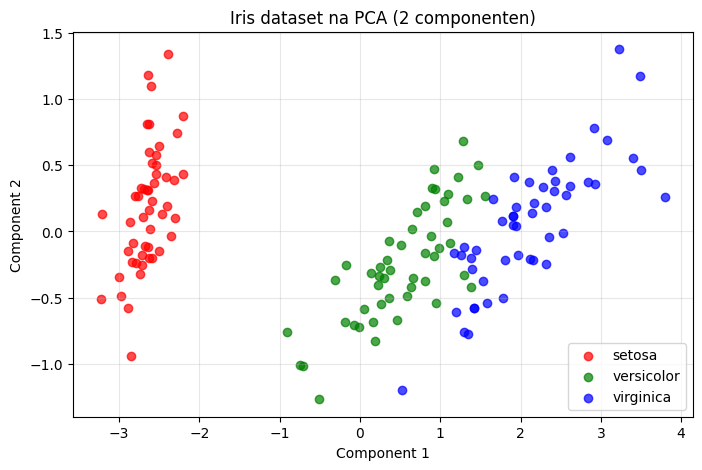

In [19]:
import matplotlib.pyplot as plt

kleuren = ['red', 'green', 'blue']
namen = iris.target_names

plt.figure(figsize=(8, 5))

for soort in range(3):
    mask = iris.target == soort
    plt.scatter(data_pca[mask, 0], data_pca[mask, 1],
                c=kleuren[soort], label=namen[soort], alpha=0.7)

plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("Iris dataset na PCA (2 componenten)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Inleveren

Lever in op CodeGrade onder **2.2 Unsupervised Learning**